In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.special import logsumexp


# matplotlib settings
# --- Publication style settings ---
plt.rcParams.update({
    # Font
    "font.family": "Times New Roman",
    "font.serif": ["Arial"],  # or other preferred serif font
    "mathtext.fontset": "cm",            # Computer Modern for math text
    "text.usetex": False,                 # Use LaTeX for text rendering]
    "pdf.fonttype": 42,                 # Use LaTeX for text rendering

    # Figure
    "figure.figsize": (6, 4),            # width, height in inches
    "figure.dpi": 150,                   # medium resolution

    # Axes
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.linewidth": 1.2,
    "axes.grid": True,                   # optional, remove if you want no grid
    "grid.linestyle": "--",
    "grid.alpha": 0.7,

    # Ticks
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    # Lines
    "lines.linewidth": 2,
    "lines.markersize": 6,

    # Legend
    "legend.fontsize": 10,
    "legend.frameon": False
})

# functions
# read_colvar function which sorts colvar for unique entries from the back (i.e., second entry retained)
def read_colvar(colvar_file):

    data = np.loadtxt(colvar_file)
    # inverse order
    data = data[::-1]
    unique_idxs = np.array(np.unique(data[:,0], return_index=True)[1]).astype(int)[::-1] # find unique indices, first occurences
    data = data[unique_idxs]
    # original order
    data = data[::-1]

    return data


path = '../OPES_multiT/ACTR/NEW_OPES_multiT_300K_2fs_80steps/'
output_path = './trial_plots_ACTR/'

/tmp/ipykernel_3856992/4058747117.py:40: RuntimeWarning: divide by zero encountered in log
  shift = np.log(len(logw))
/tmp/ipykernel_3856992/4058747117.py:40: RuntimeWarning: divide by zero encountered in log
  shift = np.log(len(logw))
/tmp/ipykernel_3856992/4058747117.py:40: RuntimeWarning: divide by zero encountered in log
  shift = np.log(len(logw))
/tmp/ipykernel_3856992/4058747117.py:40: RuntimeWarning: divide by zero encountered in log
  shift = np.log(len(logw))
/tmp/ipykernel_3856992/4058747117.py:40: RuntimeWarning: divide by zero encountered in log
  shift = np.log(len(logw))
/tmp/ipykernel_3856992/4058747117.py:40: RuntimeWarning: divide by zero encountered in log
  shift = np.log(len(logw))
/tmp/ipykernel_3856992/4058747117.py:40: RuntimeWarning: divide by zero encountered in log
  shift = np.log(len(logw))


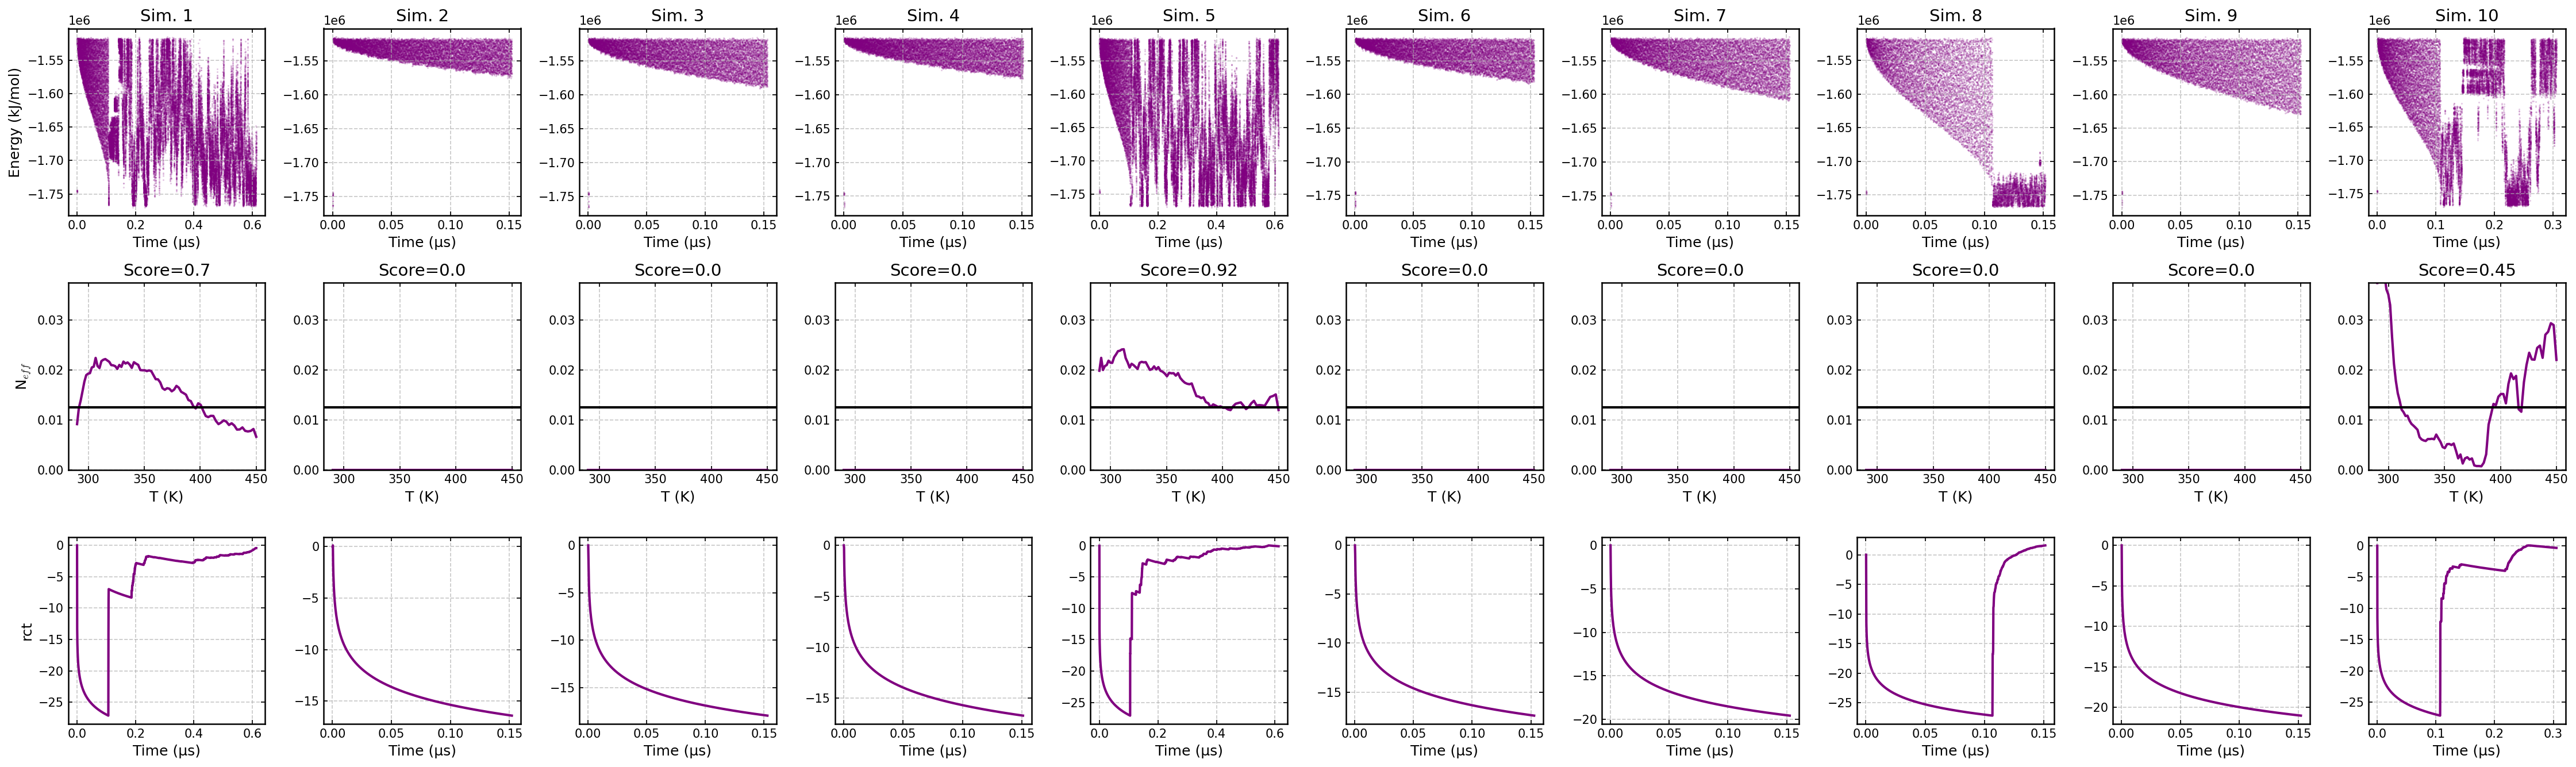

In [3]:
protein = 'ACTR'
discard_time = 200.0 # in nanoseconds
dt_per_frame = 0.01 # in nanoseconds
kb = 0.008314
T0 = 300
kbt = kb*T0
temps = np.geomspace(290, 450, 80)

# ---- define your 10 simulation directories ----
sims = [path + f"dir{i}/" for i in range(10)]

# 3 rows x N columns
fig, axes = plt.subplots(3, len(sims), figsize=(3*len(sims), 9))

for col, sim in enumerate(sims):
    name = sim.split(f'{protein}/')[1].replace('/', '-')

    # =====================
    #   Load data (energies)
    # =====================
    data = read_colvar(sim + 'COLVAR')
    bias = data[:,2][int(discard_time / dt_per_frame):] # discard initial equilibration
    ene  = data[:,1][int(discard_time / dt_per_frame):]
    time_data = data[:,0] / 1e6  # ps → μs

    # --- Row 1: Energy vs time ---
    ax1 = axes[0, col]
    ax1.scatter(time_data, data[:,1], s=0.25, alpha=0.2, rasterized=True, color = 'purple')
    ax1.set_title(f'Sim. {col+1}')
    if col == 0:
        ax1.set_ylabel("Energy (kJ/mol)")
    ax1.set_xlabel("Time (μs)")

    # =====================
    #   Neff computation
    # =====================
    neffs = []
    for T in temps:
        logw = (bias + (1 - T0/T) * ene) / (kb * T0)
        shift = np.log(len(logw))
        try:
            neff = np.exp(2 * logsumexp(logw) - logsumexp(2 * logw) - shift)
        except:
            neff = float(0)
        neffs.append(neff)
    neffs = np.array(neffs)

    score = np.sum(neffs > (1 / temps.shape[0])) / len(temps)
    score = np.round(score, 2)

    # --- Row 2: Neff vs Temp ---
    ax2 = axes[1, col]
    ax2.plot(temps, neffs, color = 'purple')
    ax2.axhline(1/temps.shape[0], color = 'black')
    ax2.set_ylim(0, (1/temps.shape[0])*3)
    if col == 0:
        ax2.set_ylabel("N$_{eff}$")
    ax2.set_xlabel("T (K)")
    ax2.set_title(f"Score={score}")

    # =====================
    #   rct convergence
    # =====================
    data_rct = read_colvar(sim + 'DELTAFS')
    rct = data_rct[:,1]
    time_rct = data_rct[:,0] / 1e6

    # --- Row 3: rct vs time ---
    ax3 = axes[2, col]
    ax3.plot(time_rct, rct, color = 'purple')
    if col == 0:
        ax3.set_ylabel("rct")
    ax3.set_xlabel("Time (μs)")

plt.tight_layout()
plt.savefig(output_path + "all_trials_ene_neff_rct.pdf")

